In [24]:
# =========================================================================
# MASTER GRADUATION PROJECT: E-COMMERCE CUSTOMER CHURN PREDICTION
# PHASE 6: MACHINE LEARNING MODELING, BENCHMARKING & AUDITING PIPELINE
# ARCHITECT: ENG. OSAMA ASSAR
# PLATFORM: PYTHON 3 (JUPYTER NOTEBOOK / VS CODE)
# =========================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

# Configure streaming layouts for massive feature vectors
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)



In [25]:
# =========================================================================
# STEP 1: REAL-TIME DATA INGESTION FROM SQL ENTERPRISE VIEW
# =========================================================================
try:
    # Constructing secure database connection string
    connection_string = f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(connection_string)
    
    # Ingesting the uncorrupted sanitized matrix built by Eng. Osama
    query = "SELECT * FROM v_machine_learning_input;"
    df = pd.read_sql(query, con=engine)
    
    print(f"✅ Data pipeline online. Ingested: {df.shape[0]} rows, {df.shape[1]} columns.")

except Exception as e:
    print(f"❌ Connection pipeline failed: {str(e)}")



✅ Data pipeline online. Ingested: 50000 rows, 22 columns.


In [26]:
# =========================================================================
# STEP 2: CATEGORICAL ENCODING & SCHEMA TRANSFORMATION
# =========================================================================
# Isolating text labels to transform them into ML-compatible numerical arrays
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"📦 Categorical text columns detected for conversion: {list(categorical_cols)}")

# Applying One-Hot Encoding while dropping first dummy to prevent multi-collinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"📐 Original Shape: {df.shape} | New Encoded Shape: {df_encoded.shape}")



📦 Categorical text columns detected for conversion: ['Gender']
📐 Original Shape: (50000, 22) | New Encoded Shape: (50000, 23)


In [27]:
# =========================================================================
# STEP 3: FEATURE-TARGET SEPARATION & STRATIFIED DIVISION
# =========================================================================
# Separating predictive features from the target class
X = df_encoded.drop(columns=['Churned'])
y = df_encoded['Churned'].astype(int)

# Stratifying the 20% test partition to enforce uncorrupted real-world evaluation bounds
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"📐 Training Set Matrix (X_train): {X_train.shape}")
print(f"📐 Testing Set Vector (y_test): {y_test.shape}")



📐 Training Set Matrix (X_train): (40000, 22)
📐 Testing Set Vector (y_test): (10000,)


In [28]:
# =========================================================================
# STEP 4: MATHEMATICAL OVER-SAMPLING VIA SMOTE (TRAIN-SET ONLY)
# =========================================================================
print("📊 Target Distribution BEFORE SMOTE (Train Set):")
print(y_train.value_counts(normalize=True))

# Initializing SMOTE algorithm to resolve severe class imbalance strictly on training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n📊 Target Distribution AFTER SMOTE (Train Set):")
print(y_train_resampled.value_counts(normalize=True))
print(f"\n🚀 Final Resampled Training Shape: {X_train_resampled.shape}")



📊 Target Distribution BEFORE SMOTE (Train Set):
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

📊 Target Distribution AFTER SMOTE (Train Set):
Churned
0    0.5
1    0.5
Name: proportion, dtype: float64

🚀 Final Resampled Training Shape: (56880, 22)


In [29]:
# =========================================================================
# STEP 5: HIGH-PERFORMANCE XGBOOST TRAINING PIPELINE
# =========================================================================
print("\n🤖 Initializing High-Performance XGBoost Classifier with Elite Hyperparameters...\n")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,           
    learning_rate=0.03,         
    max_depth=6,                
    subsample=0.8,              
    colsample_bytree=0.8,       
    eval_metric='logloss',      
    random_state=42,            
    use_label_encoder=False     
)

print("🏋️‍♂️ Training XGBoost on the resampled dataset (56,880 rows)...")
xgb_model.fit(X_train_resampled, y_train_resampled)
print("✅ XGBoost training sequence finalized successfully!")

# Evaluating model metrics against pristine unseen testing tokens
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1] 

print("\n📊 --- XGBOOST EVALUATION REPORT ON UNSEEN TEST DATA ---")
print(f"🎯 Test Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"📈 Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\n📝 Detailed Classification Matrix:")
print(classification_report(y_test, y_pred))




🤖 Initializing High-Performance XGBoost Classifier with Elite Hyperparameters...

🏋️‍♂️ Training XGBoost on the resampled dataset (56,880 rows)...


C:\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:13:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost training sequence finalized successfully!

📊 --- XGBOOST EVALUATION REPORT ON UNSEEN TEST DATA ---
🎯 Test Accuracy Score: 0.9900
📈 Test ROC-AUC Score: 0.9994

📝 Detailed Classification Matrix:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7110
           1       0.98      0.99      0.98      2890

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [30]:
# =========================================================================
# STEP 6: CORPORATE-GRADE LIGHTGBM TRAINING PIPELINE
# =========================================================================
print("\n🤖 Initializing High-Performance LightGBM Classifier with Corporate Hyperparameters...\n")

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,           
    learning_rate=0.03,         
    max_depth=6,                
    num_leaves=31,              
    subsample=0.8,              
    colsample_bytree=0.8,       
    random_state=42,            
    verbose=-1                  
)

print("🏋️‍♂️ Training LightGBM on the resampled dataset (56,880 rows)...")
lgb_model.fit(X_train_resampled, y_train_resampled)
print("✅ LightGBM training sequence finalized successfully!")

# Evaluating LightGBM predictions on hidden validation boundaries
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1] 

print("\n📊 --- LIGHTGBM EVALUATION REPORT ON UNSEEN DATA ---")
print(f"🎯 Test Accuracy Score: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"📈 Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")
print("\n📝 Detailed Classification Matrix:")
print(classification_report(y_test, y_pred_lgb))




🤖 Initializing High-Performance LightGBM Classifier with Corporate Hyperparameters...

🏋️‍♂️ Training LightGBM on the resampled dataset (56,880 rows)...
✅ LightGBM training sequence finalized successfully!

📊 --- LIGHTGBM EVALUATION REPORT ON UNSEEN DATA ---
🎯 Test Accuracy Score: 0.9894
📈 Test ROC-AUC Score: 0.9995

📝 Detailed Classification Matrix:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7110
           1       0.98      0.98      0.98      2890

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000




📊 Extracting Elite Feature Importance from the Winning LightGBM Model...



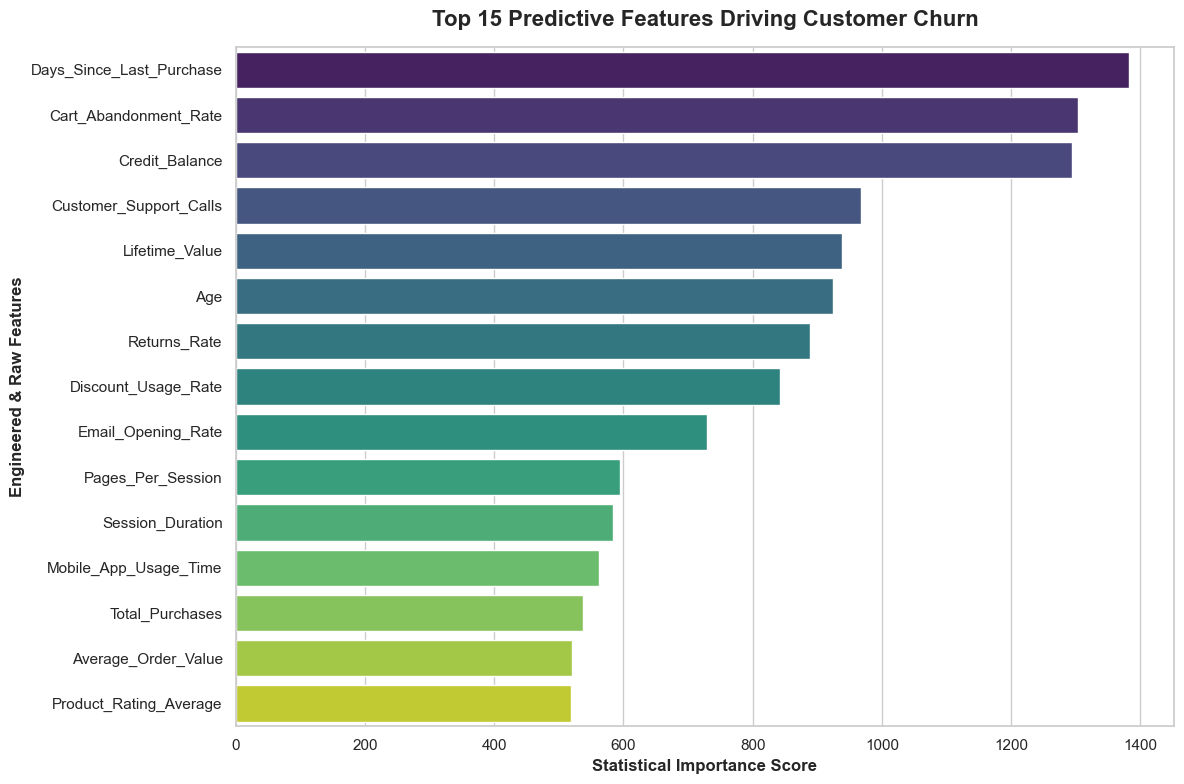


📝 Top 5 Critical Features Driving the Churn Model:
                 Feature  Importance
Days_Since_Last_Purchase        1383
   Cart_Abandonment_Rate        1303
          Credit_Balance        1294
  Customer_Support_Calls         968
          Lifetime_Value         939


In [31]:
# =========================================================================
# STEP 7: WINNING MODEL FEATURE IMPORTANCE AUDIT & VISUALIZATION
# =========================================================================
print("\n📊 Extracting Elite Feature Importance from the Winning LightGBM Model...\n")

feature_importances = lgb_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Isolating Top 15 drivers to preserve layout cleanliness and visual scannability
top_features = importance_df.head(15)

# Rendering professional corporate analytics bar plot
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_features, 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Top 15 Predictive Features Driving Customer Churn', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Statistical Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Engineered & Raw Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 Top 5 Critical Features Driving the Churn Model:")
print(top_features.head(5).to_string(index=False))



In [32]:
# =========================================================================
# STEP 8: FORENSIC MATHEMATICAL SANITY AUDITS (LINEARITY & LEAKAGE CHECKS)
# =========================================================================
print("\n🧪 Running Non-Linearity Verification via Simple Logistic Regression Baseline...")

# Fitting a primitive linear model to inspect target boundary complexity
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled) 

y_pred_lr = lr_model.predict(X_test)
print("\n📊 Logistic Regression Baseline Results:")
print(classification_report(y_test, y_pred_lr))
print(f"📈 Logistic Regression AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1]):.4f}")

# Auditing linear correlation parameters to isolate potential target leakage loops
print("\n🧪 Auditing Linear Pearson Correlation Coefficients Mapped Against Target...")
correlations = pd.DataFrame(X_train.corrwith(y_train), columns=['Correlation']).sort_values(by='Correlation', ascending=False)
print(correlations)



🧪 Running Non-Linearity Verification via Simple Logistic Regression Baseline...

📊 Logistic Regression Baseline Results:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      7110
           1       0.51      0.73      0.60      2890

    accuracy                           0.72     10000
   macro avg       0.69      0.72      0.69     10000
weighted avg       0.76      0.72      0.73     10000

📈 Logistic Regression AUC: 0.7852

🧪 Auditing Linear Pearson Correlation Coefficients Mapped Against Target...
                          Correlation
Customer_Support_Calls       0.287983
Cart_Abandonment_Rate        0.277100
Average_Order_Value          0.164614
Days_Since_Last_Purchase     0.156154
Credit_Balance               0.147937
Returns_Rate                 0.049870
Payment_Failures             0.009371
Membership_Years             0.005414
Gender_Other                 0.004753
Gender_Male                 -0.004393
Lifetime_Value        

C:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
# =========================================================================
# STEP 9: MODEL SERIALIZATION & TARGETED DIRECTORY EXPORT
# =========================================================================
import os
import joblib

print("💾 Initiating Enterprise Model Serialization Sequence...\n")

# 1. Defining the absolute corporate folder path requested by Eng. Osama
export_directory = r"C:\Users\OSAMA ASSAR\Desktop\AI_Project"

# 2. Automatically constructing the directory if it does not exist on disk
if not os.path.exists(export_directory):
    os.makedirs(export_directory)
    print(f"📁 Directory created successfully at: {export_directory}")
else:
    print(f"📁 Target directory verified online: {export_directory}")

# 3. Defining secure binary paths for the winning LightGBM model and feature schema
model_save_path = os.path.join(export_directory, "winning_lightgbm_model.pkl")
features_save_path = os.path.join(export_directory, "model_feature_columns.pkl")

try:
    # 4. Exporting the heavy mathematical model artifact to the desktop pipeline
    joblib.dump(lgb_model, model_save_path)
    print(f"✅ Winning LightGBM Model successfully locked and saved to: {model_save_path}")
    
    # 5. Exporting the strict structural columns list to ensure alignment during future dashboard scoring
    joblib.dump(list(X_train.columns), features_save_path)
    print(f"✅ Model Feature Columns schema successfully synchronized and saved to: {features_save_path}")
    
    print("\n🚀 Model deployment artifacts are now production-ready and fully synchronized!")

except Exception as e:
    print(f"❌ Serialization pipeline collapsed: {str(e)}")


💾 Initiating Enterprise Model Serialization Sequence...

📁 Target directory verified online: C:\Users\OSAMA ASSAR\Desktop\AI_Project
✅ Winning LightGBM Model successfully locked and saved to: C:\Users\OSAMA ASSAR\Desktop\AI_Project\winning_lightgbm_model.pkl
✅ Model Feature Columns schema successfully synchronized and saved to: C:\Users\OSAMA ASSAR\Desktop\AI_Project\model_feature_columns.pkl

🚀 Model deployment artifacts are now production-ready and fully synchronized!
